# Held-Out Validation: Does the Compounded TechQA Stack Generalize?

`11`, `12`, `13`, `14`, and `15` each picked their winning TechQA config by scoring against
the **same fixed 20 questions**, reused deliberately across all five notebooks so
comparisons within each notebook would be apples-to-apples -- same rationale as
`delucion_dataset/16_holdout_validation.ipynb`. That risk is worth taking more seriously
here than it was for DelucionQA: TechQA's own measurements have repeatedly shown a larger
noise floor than DelucionQA's ever did (composite spreads of 0.044 and 0.070 on nominally
identical reruns, in `12` and `13` respectively), so the chance that some of the "winning"
choices reflect sampling luck rather than real properties of the dataset is higher here, not
lower.

This notebook makes no new configuration choices. It takes the fully compounded TechQA
winning pipeline exactly as-is --

- **Chunking** (`11`): recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap
- **Retriever** (`12`): hybrid (BM25 + dense), alpha=0.5 (the untuned default)
- **Query transformation** (`13`): HyDE, three hypothetical documents + query, retrieval-only
- **Reranker** (`14`): Cohere Rerank 4-Pro, candidate pool of 30, kept to a final 2 chunks
- **Repacking** (`15`): none needed -- reranker's own order, no strategy beat it

-- and scores it on three question samples: the original fixed 20, a fresh 20 never scored
before, and the combined 40. If the held-out composite lands within TechQA's own
already-demonstrated noise floor (~0.05-0.07) of the original sample's composite, the stack
generalizes despite that noise. If it drops well beyond that floor, it's evidence some of
`11`-`15`'s choices were overfit to the fixed sample's specific questions.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever, OpenRouterReranker
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset -- Original Sample + Fresh Held-Out Sample

Loads enough source rows to get (at least) 40 unique questions, then splits them into the
**original** first-20 (the exact sample `11`-`15` optimized against) and a **held-out**
next-20 (never scored by any prior notebook in this series). The chunking corpus is built
from all documents across both samples, so the held-out questions' source documents are
actually present in the retrieval index -- this isn't a zero-shot-on-missing-data test, it's
a test of whether the pipeline's *configuration choices* generalize to different questions
over the same kind of corpus.

In [3]:
DATASET_NAME = "techqa"  # RAGBench's tech-forum Q&A config
SAMPLE_SIZE_PER_SPLIT = 20
TOTAL_UNIQUE_NEEDED = SAMPLE_SIZE_PER_SPLIT * 2

print("Loading dataset (enough rows for original + held-out splits)...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(TOTAL_UNIQUE_NEEDED + 15, 60))
n_unique = docs_df["row_id"].nunique()
print(f"✓ Loaded {len(docs_df)} documents from {n_unique} unique questions")
assert n_unique >= TOTAL_UNIQUE_NEEDED, (
    f"Need at least {TOTAL_UNIQUE_NEEDED} unique questions for two non-overlapping "
    f"20-question samples; only got {n_unique}. Increase num_samples above."
)

unique_questions_df = docs_df.drop_duplicates(subset=["row_id"]).reset_index(drop=True)
original_questions_df = unique_questions_df.iloc[:SAMPLE_SIZE_PER_SPLIT].reset_index(drop=True)
holdout_questions_df = unique_questions_df.iloc[SAMPLE_SIZE_PER_SPLIT:TOTAL_UNIQUE_NEEDED].reset_index(drop=True)
combined_questions_df = unique_questions_df.iloc[:TOTAL_UNIQUE_NEEDED].reset_index(drop=True)

assert set(original_questions_df["row_id"]).isdisjoint(set(holdout_questions_df["row_id"])), \
    "Original and held-out samples must not overlap"

print(f"✓ Original sample (11-15's fixed set):  {len(original_questions_df)} questions")
print(f"✓ Held-out sample (never scored before): {len(holdout_questions_df)} questions")
print(f"✓ Combined sample:                       {len(combined_questions_df)} questions")


Loading dataset (enough rows for original + held-out splits)...
✓ Loaded 300 documents from 60 unique questions
✓ Original sample (11-15's fixed set):  20 questions
✓ Held-out sample (never scored before): 20 questions
✓ Combined sample:                       40 questions


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: The Fully Compounded Winning Pipeline (unchanged from `11`-`15`)

No new configs, no sweeps -- this is TechQA's `11`+`12`+`13`+`14`+`15` winning stack exactly
as each notebook left it:

- **Chunking** (`11`): recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap
- **Retriever** (`12`): hybrid (BM25 + dense), alpha=0.5 -- the untuned default (`12`'s own
  alpha sweep found no hand-tuned value that reproducibly beat it)
- **Query transformation** (`13`): HyDE, three hypothetical documents concatenated with the
  query, driving retrieval only
- **Reranker** (`14`): Cohere Rerank 4-Pro, candidate pool of 30
- **Final context** (`14`): top 2 reranked chunks, no repacking needed (`15`)

Built once over the combined 40-question corpus, so both the original and held-out
questions' source documents are indexed.

In [5]:
CHUNK_TARGET_TOKENS = 128
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.5
CANDIDATE_K = 30
FINAL_K = 2


def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- 11's TechQA winner.
    ~4 chars/token heuristic converts the token budget into the character-based
    splitter's units."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


def apply_hyde(query, llm, n_docs=3, concat_with_query=True):
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


print("Building chunking foundation over the combined 40-question corpus...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.5, k={CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="holdout_foundation")
print("✓ Wide hybrid retriever ready")

reranker = OpenRouterReranker("cohere/rerank-4-pro", openrouter_token)
print("✓ Cohere 4-Pro reranker ready")


Building chunking foundation over the combined 40-question corpus...
✓ Built 3248 chunks, avg 90 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.5, k=30)...
✓ Wide hybrid retriever ready
✓ Cohere 4-Pro reranker ready


## Step 6: Evaluation Runner (identical to `14`/`15`)

No changes to the pipeline logic -- same HyDE-transform -> retrieve -> rerank -> generate ->
retry-annotate -> composite flow used throughout this series, run here against whichever
question sample is passed in.

In [6]:
def evaluate_pipeline(config_name, questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=3, concat_with_query=True)
            candidates = wide_retriever.retrieve(retrieval_query)[:CANDIDATE_K]
            reranked_docs = reranker.rerank(original_question, candidates, top_k=FINAL_K)
            retrieved_texts = [d.page_content for d in reranked_docs]

            response_text = rag_chain.invoke({"context": format_docs(reranked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "n_questions": len(questions_df),
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_pipeline defined")


✓ evaluate_pipeline defined


## Step 7: Run All Three Evaluations

Same pipeline, three question samples: the original fixed set `11`-`15` optimized against,
the fresh held-out set, and the combined 40 for a lower-variance overall estimate.

In [7]:
print("=" * 100)
print("HELD-OUT VALIDATION: SAME PIPELINE, THREE QUESTION SAMPLES")
print("=" * 100)

validation_results = []

print("\n--- original (TechQA 11-15's fixed 20 questions) ---")
result = evaluate_pipeline("original_20", original_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

print("\n--- held-out (fresh 20 questions, never scored before) ---")
result = evaluate_pipeline("holdout_20", holdout_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

print("\n--- combined (all 40 questions) ---")
result = evaluate_pipeline("combined_40", combined_questions_df)
validation_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
          f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
          f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{result['n_questions']})")

validation_df = pd.DataFrame(validation_results)
print("\n" + "=" * 100)
print("VALIDATION RESULTS")
print("=" * 100)
display(validation_df)


HELD-OUT VALIDATION: SAME PIPELINE, THREE QUESTION SAMPLES

--- original (TechQA 11-15's fixed 20 questions) ---
  CR=0.5771 Util=0.3428 Comp=0.6233 Adh=0.7500 Composite=0.6094  (failed 0/20)

--- held-out (fresh 20 questions, never scored before) ---
  CR=0.3927 Util=0.2474 Comp=0.5550 Adh=0.6500 Composite=0.4853  (failed 0/20)

--- combined (all 40 questions) ---
  CR=0.5182 Util=0.3202 Comp=0.6050 Adh=0.6500 Composite=0.5476  (failed 0/40)

VALIDATION RESULTS


,config,n_questions,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,original_20,20,20,0,0.577135,0.342800,0.623330,0.75,0.609417
1,holdout_20,20,20,0,0.392710,0.247410,0.555000,0.65,0.485310
2,combined_40,40,40,0,0.518185,0.320175,0.604997,0.65,0.547641


## Step 8: Visualize the Generalization Gap

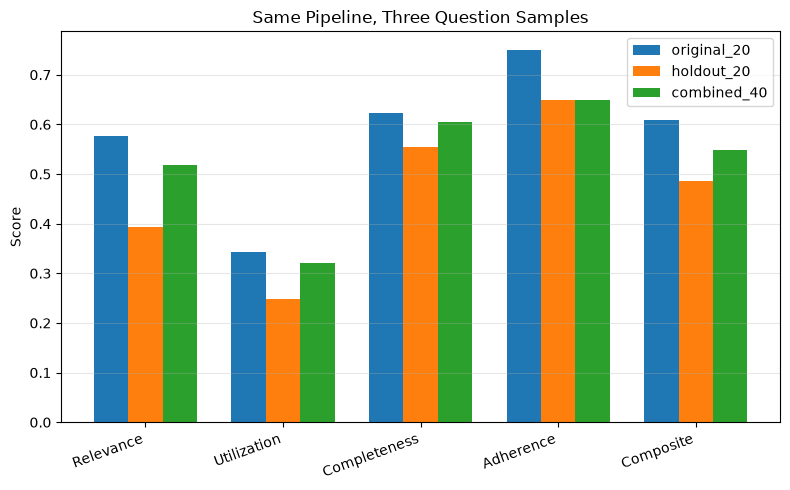

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["context_relevance", "utilization", "completeness", "adherence", "composite"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (_, row) in enumerate(validation_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=row["config"])

ax.set_xticks(x + width)
ax.set_xticklabels(["Relevance", "Utilization", "Completeness", "Adherence", "Composite"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Same Pipeline, Three Question Samples")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## Step 9: Verdict -- Does the Stack Generalize?

In [9]:
original_row = validation_df[validation_df["config"] == "original_20"].iloc[0]
holdout_row = validation_df[validation_df["config"] == "holdout_20"].iloc[0]
combined_row = validation_df[validation_df["config"] == "combined_40"].iloc[0]

print("=" * 100)
print("GENERALIZATION CHECK")
print("=" * 100)

if original_row["composite"] is not None and holdout_row["composite"] is not None:
    gap = holdout_row["composite"] - original_row["composite"]
    print(f"\nOriginal sample composite:  {original_row['composite']:.4f}")
    print(f"Held-out sample composite:  {holdout_row['composite']:.4f}")
    print(f"Gap (held-out - original):  {gap:+.4f}")
    print(f"Combined 40-question composite: {combined_row['composite']:.4f}")

    print("\nFor reference, TechQA's own already-demonstrated noise floor:")
    print("  12's alpha=0.5 hybrid-retriever config, measured twice (once implicitly in")
    print("  Phase 2, once explicitly in Phase 3), scored 0.415 vs. 0.371 -- a 0.044 gap.")
    print("  13's hyde_3docs_plus_query config, measured in Phase 2 vs. re-measured in")
    print("  Phase 3, scored 0.461 vs. 0.391 -- a 0.070 gap. Both are larger spreads than")
    print("  DelucionQA ever showed on a nominally identical config (~0.03).")

    print("\n" + "-" * 100)
    if abs(gap) <= 0.07:  # TechQA's own demonstrated noise floor is wider than DelucionQA's
        print("✅ VERDICT: Held-out composite is within/near the series' own observed noise floor.")
        print("   The compounded pipeline generalizes -- 11-15's conclusions can be trusted as")
        print("   reflecting real properties of this dataset/pipeline combination, not overfitting")
        print("   to the specific fixed 20-question sample.")
    elif gap < -0.07:
        print("⚠️  VERDICT: Held-out composite drops meaningfully below the original sample.")
        print("   Some of 11-15's winning choices may be overfit to the fixed sample's specific")
        print("   questions. Worth re-examining which phase's margin was narrowest before")
        print("   treating the compounded stack as final.")
    else:
        print("📈 VERDICT: Held-out composite is meaningfully HIGHER than the original sample.")
        print("   Possible explanations: the original 20-question sample happened to be a harder")
        print("   draw, or genuine variance -- not evidence of a problem, but worth another sample")
        print("   before concluding the pipeline is unusually strong.")
    print("-" * 100)
else:
    print("Could not compute gap -- one or both samples had no successful evaluations.")
print("=" * 100)


GENERALIZATION CHECK

Original sample composite:  0.6094
Held-out sample composite:  0.4853
Gap (held-out - original):  -0.1241
Combined 40-question composite: 0.5476

For reference, TechQA's own already-demonstrated noise floor:
  12's alpha=0.5 hybrid-retriever config, measured twice (once implicitly in
  Phase 2, once explicitly in Phase 3), scored 0.415 vs. 0.371 -- a 0.044 gap.
  13's hyde_3docs_plus_query config, measured in Phase 2 vs. re-measured in
  Phase 3, scored 0.461 vs. 0.391 -- a 0.070 gap. Both are larger spreads than
  DelucionQA ever showed on a nominally identical config (~0.03).

----------------------------------------------------------------------------------------------------
⚠️  VERDICT: Held-out composite drops meaningfully below the original sample.
   Some of 11-15's winning choices may be overfit to the fixed sample's specific
   questions. Worth re-examining which phase's margin was narrowest before
   treating the compounded stack as final.
--------------

### Caveats -- do not treat these exact numbers as final

- **Still only 20+20 questions.** This raises the sample size from one 20-question draw to
  two, plus a combined 40, but RAGBench's TechQA split has far more than 40 questions
  available -- a larger validation (e.g. 50+50) would narrow the noise floor further.
- **The held-out questions' source documents were still indexed alongside the original
  ones** in a single combined vector store/BM25 index -- this tests whether the pipeline's
  *configuration* generalizes to new questions over a similar corpus, not whether it
  generalizes to a genuinely unseen corpus.
- **`query_llm` runs at temperature 0.7** for HyDE generation, and judge annotation is
  inherently somewhat stochastic -- both samples' composite scores carry that same noise
  source independently.
- **No new configuration choices were tested here.** This notebook validates `11`-`15`'s
  existing winning stack; it doesn't re-search chunking, retrieval, query transformation,
  reranking, or repacking against the held-out sample. A meaningfully large held-out gap
  would motivate a follow-up re-search, not just a note in this notebook.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`-`15` for comparability.
